Финальный loss: 0.000835
Предсказания:
[[0.035]
 [1.   ]
 [0.958]
 [0.019]]
Ожидалось:    
[[0]
 [1]
 [1]
 [0]]
Правильно:    4 из 4
Точность:     100.0%


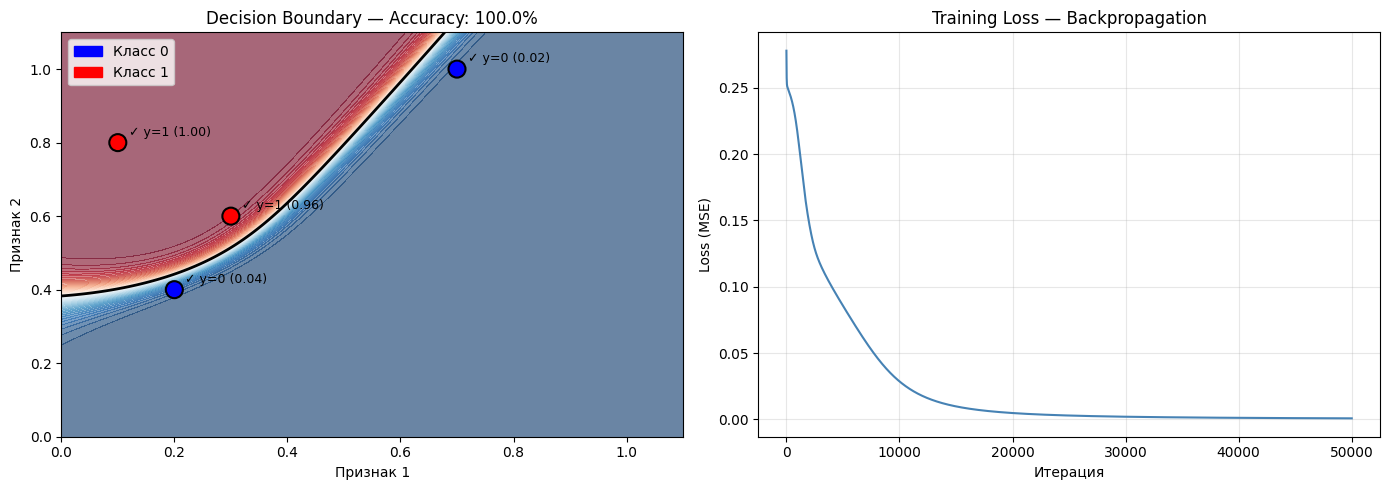

In [11]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(a):
    return a * (1 - a)

X = np.array([
    [0.2, 0.4, 0.9],
    [0.1, 0.8, 0.5],
    [0.3, 0.6, 1.0],
    [0.7, 1.0, 1.0]
])

y = np.array([[0], [1], [1], [0]])

np.random.seed(1)
W1 = np.random.randn(3, 4)
W2 = np.random.randn(4, 1)

learning_rate = 0.1
losses = []

for i in range(50000):
    h1 = sigmoid(np.dot(X, W1)) #фьючерсты 1 шы скрытый слойга косылуы
    h2 = sigmoid(np.dot(h1, W2)) #скрытый слой 2 шы выходной слойга косылуы

    loss = np.mean((y - h2) ** 2)
    losses.append(loss)

    delta2 = (y - h2) * sigmoid_derivative(h2)
    #ошибка на выходе, умноженная на производную сигмоиды (насколько сильно выход отклонился от правильного значения)
    delta1 = delta2.dot(W2.T) * sigmoid_derivative(h1)
    #ошибка скрытого слоя, рассчитанная через веса W2 и производную сигмоиды Это классический backpropagation (обратное распространение ошибки)
    W2 += h1.T.dot(delta2) * learning_rate
    W1 += X.T.dot(delta1) * learning_rate

#Точность модели 
predictions = (h2 >= 0.5).astype(int)   #если предсказание >= 0.5 → класс 1, иначе 0
correct = np.sum(predictions == y)       # считаем сколько правильных ответов
accuracy = correct / len(y) * 100        #переводим в проценты

print(f"Финальный loss: {losses[-1]:.6f}")
print(f"Предсказания:\n{h2.round(3)}")
print(f"Ожидалось:    \n{y}")
print(f"Правильно:    {correct} из {len(y)}")
print(f"Точность:     {accuracy:.1f}%")

#Decision Boundary 
fixed_feat = np.mean(X[:, 2])

xx, yy = np.meshgrid(np.linspace(0, 1.1, 300),
                     np.linspace(0, 1.1, 300))

grid = np.c_[xx.ravel(), yy.ravel(), np.full(xx.size, fixed_feat)]
grid_h1 = sigmoid(np.dot(grid, W1))
grid_h2 = sigmoid(np.dot(grid_h1, W2))
Z = grid_h2.reshape(xx.shape)

#Два графика рядом
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#График 1 Decision Boundary 
ax1 = axes[0]
ax1.contourf(xx, yy, Z, levels=50, cmap='RdBu_r', alpha=0.6)
ax1.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2)

colors = ['blue' if label == 0 else 'red' for label in y.ravel()]
ax1.scatter(X[:, 0], X[:, 1], c=colors, s=150,
            edgecolors='black', linewidths=1.5, zorder=5)

for i in range(len(X)):
    status = "✓" if predictions[i][0] == y[i][0] else "✗"   #галочка если правильно
    ax1.annotate(f"{status} y={y[i][0]} ({h2[i][0]:.2f})",
                 (X[i, 0], X[i, 1]),
                 textcoords="offset points", xytext=(8, 5), fontsize=9)

#Точность прямо на графике
ax1.set_title(f"Decision Boundary — Accuracy: {accuracy:.1f}%")
ax1.set_xlabel("Признак 1")
ax1.set_ylabel("Признак 2")

from matplotlib.patches import Patch
ax1.legend(handles=[Patch(color='blue', label='Класс 0'),
                    Patch(color='red',  label='Класс 1')], loc='upper left')

#График 2 Training Loss 
ax2 = axes[1]
ax2.plot(losses, color='steelblue', linewidth=1.5)
ax2.set_xlabel("Итерация")
ax2.set_ylabel("Loss (MSE)")
ax2.set_title("Training Loss — Backpropagation")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("decision_boundary.png", dpi=150)
plt.show()